In [6]:
# ── CELDA 1: Importaciones ───────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

print("\n⚠️ Nota: El árbol CART no requiere StandardScaler.")
print("   Se trabajará directamente con las variables originales.")

INFO:scripts.database:Conectando a la base de datos...
INFO:scripts.database:✅ Metadata cargada correctamente


✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2

⚠️ Nota: El árbol CART no requiere StandardScaler.
   Se trabajará directamente con las variables originales.


In [7]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────

SQL_QUERY = """
SELECT
    p.nombre_comun,
    p.region,
    p.subregion,
    dp.poblacion,
    dp.area_km2,
    dp.latitud,
    dp.longitud,
    dp.fecha_extraccion
FROM datos_paises dp
JOIN paises p ON dp.pais_id = p.id
ORDER BY dp.fecha_extraccion;
"""

with engine.connect() as conn:
    df_paises = pd.read_sql(
        text(SQL_QUERY),
        conn
    )

# Variable objetivo para clasificación
# 1 = País grande, 0 = País pequeño/mediano
umbral_area = df_paises['area_km2'].median()

df_paises['es_grande'] = np.where(
    df_paises['area_km2'] > umbral_area,
    1,
    0
)

print(f"✅ Datos cargados: {df_paises.shape[0]:,} filas × {df_paises.shape[1]} columnas")

print("\nColumnas disponibles:")
print(df_paises.columns.tolist())

print("\nBalance de la variable objetivo:")

bal = df_paises['es_grande'].value_counts()
pct = df_paises['es_grande'].value_counts(normalize=True) * 100

print(f"   País grande (1): {bal.get(1, 0):,} ({pct.get(1, 0):.1f}%)")
print(f"   País pequeño/mediano (0): {bal.get(0, 0):,} ({pct.get(0, 0):.1f}%)")

print(f"\n📏 Umbral de clasificación: {umbral_area:,.2f} km²")

df_paises.head()

✅ Datos cargados: 2,069 filas × 9 columnas

Columnas disponibles:
['nombre_comun', 'region', 'subregion', 'poblacion', 'area_km2', 'latitud', 'longitud', 'fecha_extraccion', 'es_grande']

Balance de la variable objetivo:
   País grande (1): 1,033 (49.9%)
   País pequeño/mediano (0): 1,036 (50.1%)

📏 Umbral de clasificación: 6,408,020.80 km²


,nombre_comun,region,subregion,poblacion,area_km2,latitud,longitud,fecha_extraccion,es_grande
0,Norte Bosqueland 648,Asia,Eastern Asia,214509641,15878973.37,50.5243,109.5778,2025-12-16 17:15:48.946832,1
1,Lago Claridad 40,Africa,Northern Africa,6661789,3885761.58,13.6023,46.8371,2025-12-16 17:24:40.941045,0
2,Isla Lunaria 770,Americas,Caribbean,51660444,3215144.79,-29.3930,-69.6842,2025-12-16 18:17:24.948051,0
3,Costa Terranova 32,Americas,North America,236407726,2214299.75,60.3611,-152.0686,2025-12-16 19:03:13.940971,0
4,Isla Libertad 77,Americas,North America,72524334,16223801.61,46.5863,-71.3108,2025-12-16 19:31:28.941389,1


In [8]:
# ── CELDA 3: Validación y Exploración ────────────────────────

print("=" * 60)
print("VALIDACIÓN DEL DATASET")
print("=" * 60)

# Tipos de datos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(
    df_paises.dtypes.to_frame('dtype').join(
        df_paises.isnull().sum().to_frame('nulos')
    )
)

# Balance de clases
balance = df_paises['es_grande'].value_counts()
pct = df_paises['es_grande'].value_counts(normalize=True) * 100

print("\n🎯 Balance de la variable objetivo:")
print(f"   País grande (1): {balance.get(1, 0):>5,} ({pct.get(1, 0):.1f}%)")
print(f"   País pequeño/mediano (0): {balance.get(0, 0):>5,} ({pct.get(0, 0):.1f}%)")

# Distribución por región
print("\n🌍 Distribución por región:")
print(
    df_paises['region']
    .value_counts()
    .to_string()
)

# Vista previa
print("\n📋 Primeras filas:")
df_paises.head()

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                           dtype  nulos
nombre_comun              object      0
region                    object      0
subregion                 object      0
poblacion                  int64      0
area_km2                 float64      0
latitud                  float64      0
longitud                 float64      0
fecha_extraccion  datetime64[ns]      0
es_grande                  int64      0

🎯 Balance de la variable objetivo:
   País grande (1): 1,033 (49.9%)
   País pequeño/mediano (0): 1,036 (50.1%)

🌍 Distribución por región:
region
Europe       438
Americas     434
Africa       422
Asia         404
Oceania      364
Antarctic      7

📋 Primeras filas:


,nombre_comun,region,subregion,poblacion,area_km2,latitud,longitud,fecha_extraccion,es_grande
0,Norte Bosqueland 648,Asia,Eastern Asia,214509641,15878973.37,50.5243,109.5778,2025-12-16 17:15:48.946832,1
1,Lago Claridad 40,Africa,Northern Africa,6661789,3885761.58,13.6023,46.8371,2025-12-16 17:24:40.941045,0
2,Isla Lunaria 770,Americas,Caribbean,51660444,3215144.79,-29.3930,-69.6842,2025-12-16 18:17:24.948051,0
3,Costa Terranova 32,Americas,North America,236407726,2214299.75,60.3611,-152.0686,2025-12-16 19:03:13.940971,0
4,Isla Libertad 77,Americas,North America,72524334,16223801.61,46.5863,-71.3108,2025-12-16 19:31:28.941389,1


In [9]:
# ── CELDA 4: Preprocesamiento ────────────────────────────────

df = df_paises.copy()

# 4.1 Manejo de fecha
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])

df['mes'] = df['fecha_extraccion'].dt.month
df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek

# 4.2 Relleno de nulos en variables numéricas
num_cols = [
    'poblacion',
    'area_km2',
    'latitud',
    'longitud'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.3 One-Hot Encoding para variables categóricas
df = pd.get_dummies(
    df,
    columns=['region', 'subregion'],
    drop_first=True,
    dtype=int
)

# 4.4 Definir X e y
# IMPORTANTE:
# Quitamos area_km2 porque es la variable usada para crear es_grande.
# Si la dejamos, el modelo aprende directamente la regla y no sería justo.
drop_cols = [
    'es_grande',
    'fecha_extraccion',
    'nombre_comun',
    'area_km2'
]

X = df.drop(columns=drop_cols)
y = df['es_grande']

print("✅ Preprocesamiento completado")
print(f"\nShape X: {X.shape}")

print("\nColumnas finales:")
print(X.columns.tolist())

print(
    f"\nClases en y → "
    f"0: {(y==0).sum():,} | "
    f"1: {(y==1).sum():,}"
)

print(
    "\n⚠️ No se aplica escalado, porque los árboles CART no lo requieren."
)

print(
    "\n📌 Nota: se eliminó 'area_km2' de las variables predictoras "
    "para evitar fuga de información."
)

✅ Preprocesamiento completado

Shape X: (2069, 35)

Columnas finales:
['poblacion', 'latitud', 'longitud', 'mes', 'dia_semana', 'region_Americas', 'region_Antarctic', 'region_Asia', 'region_Europe', 'region_Oceania', 'subregion_Australia and New Zealand', 'subregion_Caribbean', 'subregion_Central America', 'subregion_Central Asia', 'subregion_Central Europe', 'subregion_Eastern Africa', 'subregion_Eastern Asia', 'subregion_Eastern Europe', 'subregion_Melanesia', 'subregion_Micronesia', 'subregion_Middle Africa', 'subregion_North America', 'subregion_Northern Africa', 'subregion_Northern Europe', 'subregion_Polynesia', 'subregion_South America', 'subregion_South-Eastern Asia', 'subregion_Southeast Asia', 'subregion_Southeast Europe', 'subregion_Southern Africa', 'subregion_Southern Asia', 'subregion_Southern Europe', 'subregion_Western Africa', 'subregion_Western Asia', 'subregion_Western Europe']

Clases en y → 0: 1,036 | 1: 1,033

⚠️ No se aplica escalado, porque los árboles CART no l

In [10]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────

def entrenar_evaluar(
    X,
    y,
    test_size,
    random_state=42,
    nombre="Split",
    max_depth=None
):
    """
    Entrena un DecisionTreeClassifier.

    Objetivo:
    1 = País grande
    0 = País pequeño/mediano

    Nota:
    area_km2 fue eliminada de X para evitar fuga de información.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre': nombre,
        'train_size': len(X_train),
        'test_size': len(X_test),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'fpr': fpr,
        'tpr': tpr,
        'y_test': y_test,
        'y_pred': y_pred,
        'modelo': modelo,
    }


print("✅ Función entrenar_evaluar definida correctamente")
print("   Modelo: DecisionTreeClassifier")
print("   Objetivo: clasificar países grandes y pequeños/medianos")
print("   Nota: area_km2 no se usa como variable predictora")

✅ Función entrenar_evaluar definida correctamente
   Modelo: DecisionTreeClassifier
   Objetivo: clasificar países grandes y pequeños/medianos
   Nota: area_km2 no se usa como variable predictora


In [11]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────

resultados = [

    entrenar_evaluar(
        X,
        y,
        test_size=0.20,
        nombre="Split 80/20"
    ),

    entrenar_evaluar(
        X,
        y,
        test_size=0.30,
        nombre="Split 70/30"
    ),

    entrenar_evaluar(
        X,
        y,
        test_size=0.40,
        nombre="Split 60/40"
    ),

]

print("=" * 75)
print("      MÉTRICAS COMPARATIVAS — CLASIFICACIÓN DE PAÍSES")
print("            Árbol de Decisión CART")
print("=" * 75)

header = (
    f"{'Split':<15}"
    f"{'Train':>8}"
    f"{'Test':>8}"
    f"{'Acc':>8}"
    f"{'Prec':>8}"
    f"{'Recall':>8}"
    f"{'F1':>8}"
    f"{'AUC':>8}"
)

print(header)
print("-" * 75)

for r in resultados:

    print(
        f"{r['nombre']:<15}"
        f"{r['train_size']:>8,}"
        f"{r['test_size']:>8,}"
        f"{r['accuracy']:>8.4f}"
        f"{r['precision']:>8.4f}"
        f"{r['recall']:>8.4f}"
        f"{r['f1']:>8.4f}"
        f"{r['roc_auc']:>8.4f}"
    )

print("=" * 75)

      MÉTRICAS COMPARATIVAS — CLASIFICACIÓN DE PAÍSES
            Árbol de Decisión CART
Split             Train    Test     Acc    Prec  Recall      F1     AUC
---------------------------------------------------------------------------
Split 80/20       1,655     414  0.7464  0.7237  0.7971  0.7586  0.8010
Split 70/30       1,448     621  0.7746  0.7815  0.7613  0.7712  0.8502
Split 60/40       1,241     828  0.7355  0.7256  0.7554  0.7402  0.8094


🏆 Mejor max_depth según F1-Score (test): 8
   F1-Score test en depth=8: 0.7800


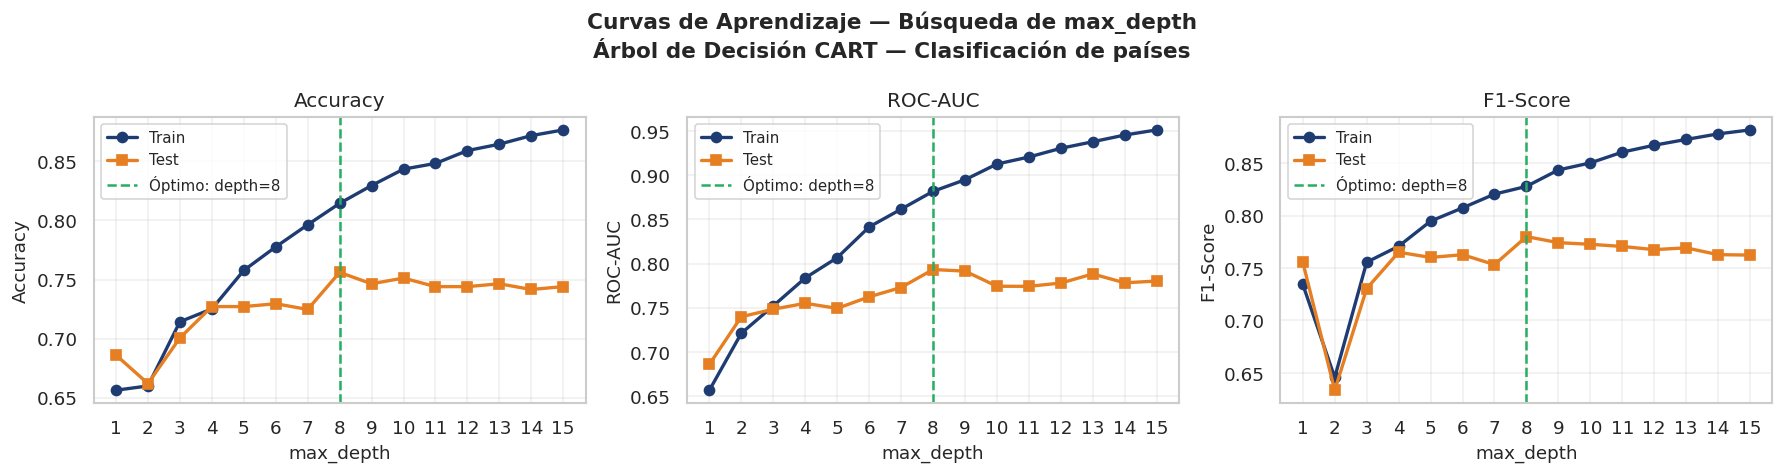

✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_paises.png


In [16]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

profundidades = range(1, 16)

acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train, f1_test = [], []

for d in profundidades:

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )

    modelo.fit(X_tr, y_tr)

    # Train
    acc_train.append(accuracy_score(y_tr, modelo.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, modelo.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, modelo.predict(X_tr), zero_division=0))

    # Test
    acc_test.append(accuracy_score(y_te, modelo.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, modelo.predict(X_te), zero_division=0))


# Mejor max_depth según F1 en prueba
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]

print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")


# ── Gráfico: curvas de entrenamiento vs prueba ───────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

fig.suptitle(
    'Curvas de Aprendizaje — Búsqueda de max_depth\n'
    'Árbol de Decisión CART — Clasificación de países',
    fontsize=13,
    fontweight='bold'
)

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC', auc_train, auc_test),
    ('F1-Score', f1_train, f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):

    ax.plot(
        profundidades,
        train_vals,
        'o-',
        color='#1e3c72',
        lw=2,
        label='Train'
    )

    ax.plot(
        profundidades,
        test_vals,
        's-',
        color='#e67e22',
        lw=2,
        label='Test'
    )

    ax.axvline(
        x=mejor_depth,
        color='#27ae60',
        linestyle='--',
        lw=1.5,
        label=f'Óptimo: depth={mejor_depth}'
    )

    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))
    ax.grid(alpha=0.3)


plt.tight_layout()

plt.savefig(
    '../data/graficas/max_depth_arbol_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_paises.png")

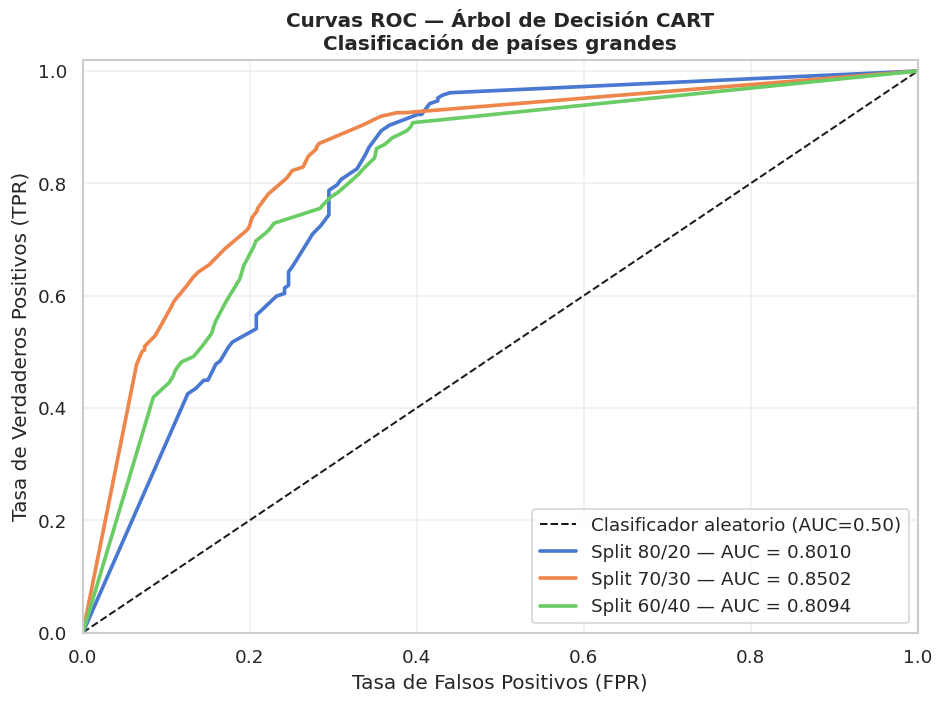

✅ Curvas ROC guardadas en data/graficas/roc_arbol_paises.png


In [13]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────

plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1.2,
    label='Clasificador aleatorio (AUC=0.50)'
)

for r in resultados:
    plt.plot(
        r['fpr'],
        r['tpr'],
        linewidth=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')

plt.title(
    'Curvas ROC — Árbol de Decisión CART\n'
    'Clasificación de países grandes',
    fontweight='bold'
)

plt.legend(loc='lower right')
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/roc_arbol_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Curvas ROC guardadas en data/graficas/roc_arbol_paises.png")

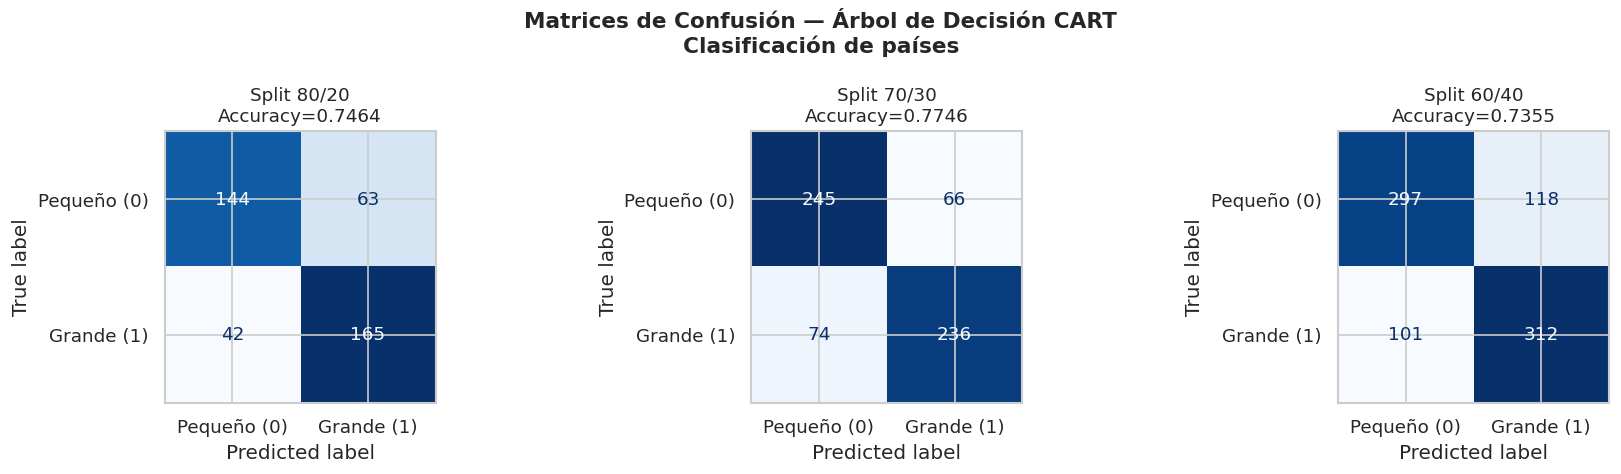

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_paises.png


In [14]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

fig.suptitle(
    'Matrices de Confusión — Árbol de Decisión CART\nClasificación de países',
    fontsize=13,
    fontweight='bold'
)

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(
        r['y_test'],
        r['y_pred']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            'Pequeño (0)',
            'Grande (1)'
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    '../data/graficas/confusion_arbol_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_paises.png")

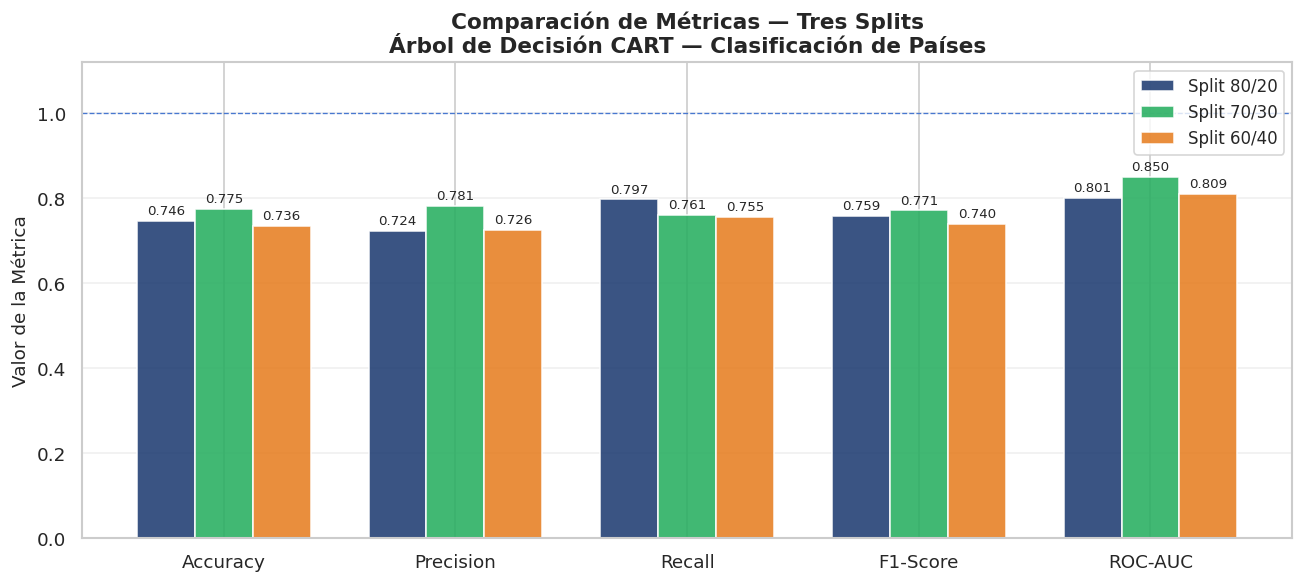

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_paises.png


In [15]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────

metricas_nombres = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

etiquetas = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

# Colores por split
COLORS = [
    '#1e3c72',  # Split 80/20
    '#27ae60',  # Split 70/30
    '#e67e22'   # Split 60/40
]

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):

    valores = [
        r[m] for m in metricas_nombres
    ]

    barras = ax.bar(
        x + i * width,
        valores,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(
        barras,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)

ax.set_ylim([0, 1.12])

ax.set_ylabel(
    'Valor de la Métrica',
    fontsize=11
)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Árbol de Decisión CART — Clasificación de Países',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.axhline(
    y=1.0,
    linewidth=0.8,
    linestyle='--'
)

ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    '../data/graficas/metricas_comparativas_arbol_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_paises.png")

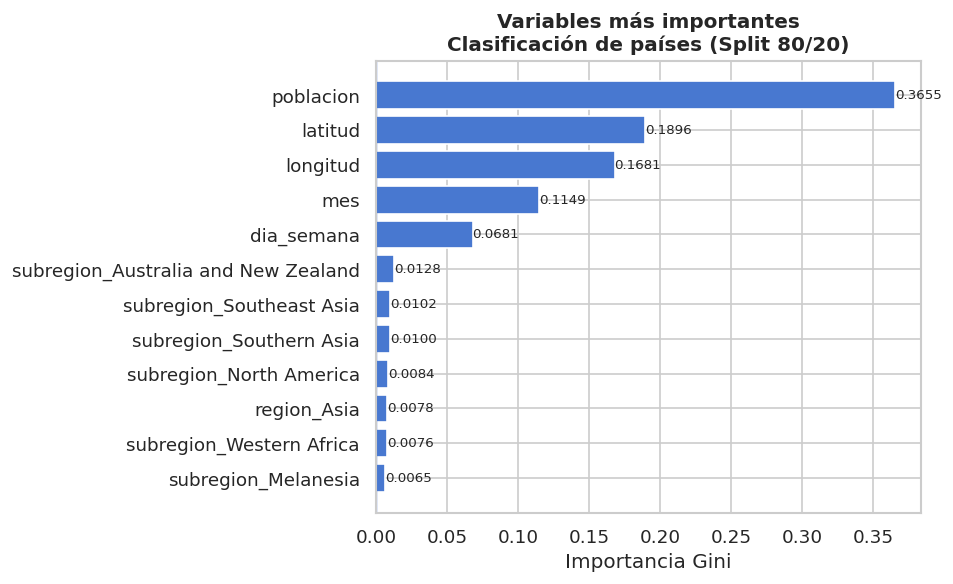

✅ Feature importance guardada en data/graficas/feature_importance_paises.png

📊 Suma total de importancias: 1.000000

🏆 Top 5 variables más importantes:
poblacion     0.365508
latitud       0.189562
longitud      0.168058
mes           0.114886
dia_semana    0.068098


In [16]:
# ── CELDA 11: Importancia de variables ───────────────────────

# Tomamos como referencia el modelo del split 80/20
modelo_ref = resultados[0]['modelo']

# Calcular importancia de variables
importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=X.columns
)

# Ordenar y tomar top variables
importancias_ord = (
    importancias
    .sort_values(ascending=True)
    .tail(12)
)

# Visualización
plt.figure(figsize=(8, 5))

barras = plt.barh(
    importancias_ord.index,
    importancias_ord.values
)

plt.xlabel(
    'Importancia Gini'
)

plt.title(
    'Variables más importantes\nClasificación de países (Split 80/20)',
    fontweight='bold'
)

plt.axvline(
    x=0,
    linewidth=0.8
)

# Mostrar valores
for bar, valor in zip(barras, importancias_ord.values):

    if valor > 0:

        plt.text(
            valor,
            bar.get_y() + bar.get_height()/2,
            f'{valor:.4f}',
            va='center',
            fontsize=8
        )

plt.tight_layout()

plt.savefig(
    '../data/graficas/feature_importance_paises.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Feature importance guardada en data/graficas/feature_importance_paises.png")

print(
    f"\n📊 Suma total de importancias: "
    f"{importancias.sum():.6f}"
)

print("\n🏆 Top 5 variables más importantes:")
print(
    importancias
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

In [17]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────

resumen = pd.DataFrame([{
    'Split': r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba': r['test_size'],
    'Accuracy': round(r['accuracy'], 4),
    'Precision': round(r['precision'], 4),
    'Recall': round(r['recall'], 4),
    'F1-Score': round(r['f1'], 4),
    'ROC-AUC': round(r['roc_auc'], 4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 70)
print("        TABLA FINAL DE MÉTRICAS — CLASIFICACIÓN DE PAÍSES")
print("=" * 70)

display(
    resumen.style
    .background_gradient(
        cmap='Greens',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .format(
        '{:.4f}',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    )
    .set_caption(
        "Árbol de Decisión CART — Clasificación Binaria: País grande vs pequeño/mediano"
    )
)

print("\n📌 Comparación de modelos:")
print("   · Regresión Logística — modelo lineal, requiere mejor preparación de variables.")
print("   · Árbol CART          — modelo no lineal, no requiere escalado y permite interpretar reglas.")
print(f"\n   Mejor max_depth encontrado: {mejor_depth}")

        TABLA FINAL DE MÉTRICAS — CLASIFICACIÓN DE PAÍSES


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1655,414,0.7464,0.7237,0.7971,0.7586,0.8010
Split 70/30,1448,621,0.7746,0.7815,0.7613,0.7712,0.8502
Split 60/40,1241,828,0.7355,0.7256,0.7554,0.7402,0.8094



📌 Comparación de modelos:
   · Regresión Logística — modelo lineal, requiere mejor preparación de variables.
   · Árbol CART          — modelo no lineal, no requiere escalado y permite interpretar reglas.

   Mejor max_depth encontrado: 8
